## Two‑Stage Fine‑Tuning of XLS‑R for ASR
This notebook implements a two‑stage fine‑tuning pipeline for the multilingual XLS‑R (Wav2Vec2‑XLS‑R‑300M) speech recognition model. The goal is to adapt XLS‑R to English speech using a combination of clean and real‑world datasets.
### 1. Datasets
- LibriSpeech train‑clean‑360
Clean, high‑quality read English speech. Used for Stage‑1 base fine‑tuning.
- Common Voice v24 EN‑AU
Diverse, accented Australian English speech. Used for Stage‑2 domain adaptation.
### 2. Vocabulary & Processor
A character‑level vocabulary is built from both datasets and used to create:
- a custom CTC tokenizer
- a Wav2Vec2 feature extractor
- a combined Wav2Vec2Processor
### 3. Stage‑1 Training (LibriSpeech)
The XLS‑R‑300M model is fine‑tuned on LibriSpeech(30,000) to learn clean English acoustic patterns.
### 4. Stage‑2 Training (Common Voice EN‑AU)
The Stage‑1 model is further fine‑tuned on Australian English speech(20,000) to adapt to:
- accent variation
- real‑world recording conditions
- spontaneous speech patterns
### 5. Inference & Evaluation
The final model is evaluated on a 200‑sample Common Voice subset using:
- Word Error Rate (WER)
- Character Error Rate (CER)
Sample predictions and error visualizations are also generated.

## Step 1: Install Compatible Packages

In [ ]:
# Pin stable, mutually compatible versions tested on Kaggle P100
# transformers 4.40.x: as_target_processor() is present but deprecated (warns only)
# transformers >=4.46: as_target_processor() raises AttributeError
# datasets 2.20.0: stable HF datasets, no breaking changes
# jiwer 3.0.x: stable API for WER/CER
!pip install -q \
    transformers==4.46.3 \
    accelerate==0.34.2 \
    peft==0.13.2 \
    datasets==2.20.0 \
    jiwer==3.0.4 \
    --upgrade --quiet

print("Done installing packages.")

In [2]:
import transformers, datasets, torchaudio, torch

print("transformers :", transformers.__version__)
print("datasets     :", datasets.__version__)
print("torchaudio   :", torchaudio.__version__)
print("torch        :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

transformers : 4.46.3
datasets     : 2.20.0
torchaudio   : 2.9.0+cu126
torch        : 2.9.0+cu126
CUDA available: True
GPU: Tesla P100-PCIE-16GB


## Step 2: Load LibriSpeech Data

In [3]:
import os
import pandas as pd

def load_librispeech(base_path):
    """
    Loads LibriSpeech audio paths + transcripts into a DataFrame.
    Transcripts are lowercased here at the source so everything is
    consistent downstream (vocab, tokenizer, labels).
    """
    data = []
    for speaker in os.listdir(base_path):
        speaker_path = os.path.join(base_path, speaker)
        if not os.path.isdir(speaker_path):
            continue
        for chapter in os.listdir(speaker_path):
            chapter_path = os.path.join(speaker_path, chapter)
            if not os.path.isdir(chapter_path):
                continue
            trans_file = os.path.join(chapter_path, f"{speaker}-{chapter}.trans.txt")
            if not os.path.exists(trans_file):
                continue
            with open(trans_file, "r") as f:
                lines = f.readlines()
            trans_dict = {}
            for line in lines:
                parts = line.strip().split(" ", 1)
                if len(parts) == 2:
                    # lowercase transcript at load time
                    trans_dict[parts[0]] = parts[1].lower()
            for file in os.listdir(chapter_path):
                if file.endswith(".flac"):
                    audio_id = file.replace(".flac", "")
                    if audio_id in trans_dict:
                        data.append({
                            "audio_path": os.path.join(chapter_path, file),
                            "transcript": trans_dict[audio_id]
                        })
    return pd.DataFrame(data)

librispeech_path = "/kaggle/input/datasets/pypiahmad/librispeech-asr-corpus/train-clean-360/LibriSpeech/train-clean-360"
df_librispeech = load_librispeech(librispeech_path)

print("Total LibriSpeech samples loaded:", len(df_librispeech))
df_librispeech.head(3)

Total LibriSpeech samples loaded: 104014


,audio_path,transcript
0,/kaggle/input/datasets/pypiahmad/librispeech-a...,the old gentleman thought that two handsomer o...
1,/kaggle/input/datasets/pypiahmad/librispeech-a...,the young men stepped up on either hand of bro...
2,/kaggle/input/datasets/pypiahmad/librispeech-a...,when there came one evening per favour of mist...


## Step 3: Load Common Voice EN-AU Data

In [4]:
cv_base = "/kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU"

cv_df = pd.read_csv(os.path.join(cv_base, "commonvoice-v24_en-AU.csv"))
cv_df["audio_path"] = cv_df["path"].apply(lambda x: os.path.join(cv_base, "audio_files", x))
cv_df = cv_df.rename(columns={"sentence": "transcript"})
# lowercase transcripts at load time
cv_df["transcript"] = cv_df["transcript"].str.lower()
cv_df = cv_df[["audio_path", "transcript"]].dropna().reset_index(drop=True)

print("Total Common Voice samples loaded:", len(cv_df))
cv_df.head(3)

Total Common Voice samples loaded: 55673


,audio_path,transcript
0,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,princess vilas herself also contributed person...
1,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,he has also served in the chamber of deputies.
2,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,most of his subjects were found in devon and c...


## Step 4: Subsample Datasets

In [5]:
# Stage 1: LibriSpeech subset
df_librispeech = df_librispeech.sample(n=30000, random_state=42).reset_index(drop=True)
print("LibriSpeech training subset:", len(df_librispeech))

# Stage 2: Common Voice subset (sampled later, defined here for vocab building)
cv_df_stage2 = cv_df.sample(n=20000, random_state=42).reset_index(drop=True)
print("Common Voice Stage-2 subset:", len(cv_df_stage2))

LibriSpeech training subset: 30000
Common Voice Stage-2 subset: 20000


## Step 5: Build Character-Level Vocabulary

In [6]:
import json
from collections import Counter
import re
import unicodedata

def normalize_text(text):
    """Normalize text: lowercase, remove non-alphabetic except apostrophe."""
    text = text.lower()
    text = unicodedata.normalize("NFKD", text)
    text = re.sub(r"[^a-z' ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_vocab(df_list):
    counter = Counter()
    for df in df_list:
        for text in df["transcript"]:
            # normalize before counting chars
            counter.update(list(normalize_text(text)))
    return counter

vocab_counter = extract_vocab([df_librispeech, cv_df_stage2])

# Build vocab dict; space is mapped to word-boundary token "|"
vocab_list = sorted(vocab_counter.keys())
vocab = {char: idx for idx, char in enumerate(vocab_list)}

# Map space to the word-delimiter token
if " " in vocab:
    vocab["|"] = vocab[" "]
else:
    vocab["|"] = len(vocab)

vocab["[UNK]"] = len(vocab)
vocab["[PAD]"] = len(vocab)

with open("vocab.json", "w") as f:
    json.dump(vocab, f, ensure_ascii=False)

print(f"Vocab size: {len(vocab)}")
print("Sample chars:", list(vocab.keys())[:20])

Vocab size: 31
Sample chars: [' ', "'", 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r']


## Step 6: Initialize Processor and Load XLS-R Model

In [7]:
from transformers import Wav2Vec2CTCTokenizer, Wav2Vec2FeatureExtractor, Wav2Vec2Processor

tokenizer = Wav2Vec2CTCTokenizer(
    "vocab.json",
    unk_token="[UNK]",
    pad_token="[PAD]",
    word_delimiter_token="|"
)

feature_extractor = Wav2Vec2FeatureExtractor(
    feature_size=1,
    sampling_rate=16000,
    padding_value=0.0,
    do_normalize=True,
    return_attention_mask=True
)

processor = Wav2Vec2Processor(
    feature_extractor=feature_extractor,
    tokenizer=tokenizer
)

print("Processor loaded. Vocab size:", len(tokenizer))

Processor loaded. Vocab size: 33


In [8]:
from transformers import Wav2Vec2ForCTC
import torch

model = Wav2Vec2ForCTC.from_pretrained(
    "facebook/wav2vec2-xls-r-300m",
    ctc_loss_reduction="mean",
    pad_token_id=processor.tokenizer.pad_token_id,
    vocab_size=len(processor.tokenizer),
)

# Freeze the feature encoder (CNN layers) — standard practice for XLS-R fine-tuning
model.freeze_feature_encoder()

print("Model loaded. Feature encoder frozen.")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f}M")
print(f"Total params:     {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

2026-03-06 21:32:55.268558: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772832775.293967     258 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772832775.301739     258 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772832775.321445     258 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772832775.321477     258 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772832775.321480     258 computation_placer.cc:177] computation placer alr

Model loaded. Feature encoder frozen.
Trainable params: 311.3M
Total params:     315.5M


## Step 7: PyTorch Dataset with Memory-Safe Audio Loading

In [9]:
import torch
import torchaudio
from torch.utils.data import Dataset, random_split

class ASRDataset(Dataset):
    """
    Lazy-loading dataset: audio is read from disk only when __getitem__ is called.
    Transcripts are normalized at construction time to avoid repeated work.
    Memory footprint = only the DataFrame (paths + text strings), not audio arrays.
    """
    def __init__(self, df, processor, max_audio_len_sec=15.0):
        """
        Args:
            max_audio_len_sec: skip audio files longer than this to prevent OOM
                               on P100 (16 GB VRAM). 15s is safe for batch_size=2.
        """
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.max_samples = int(max_audio_len_sec * 16000)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["audio_path"]
        text = normalize_text(row["transcript"])

        # Load audio
        speech, sr = torchaudio.load(path)
        if sr != 16000:
            speech = torchaudio.functional.resample(speech, sr, 16000)
        speech = speech.squeeze().numpy()

        # Truncate very long utterances to avoid VRAM spikes
        if len(speech) > self.max_samples:
            speech = speech[:self.max_samples]

        # Feature extraction (returns normalized float32 array)
        input_values = self.processor(
            speech,
            sampling_rate=16000,
            return_tensors="pt"
        ).input_values[0]

        # tokenize the NORMALIZED, LOWERCASED text
        with self.processor.as_target_processor():
            labels = self.processor.tokenizer(text).input_ids

        return {
            "input_values": input_values,
            "labels": torch.tensor(labels, dtype=torch.long),
        }

print("ASRDataset class defined.")

ASRDataset class defined.


In [10]:
# Stage 1 train/val split (99% / 1%)
full_dataset = ASRDataset(df_librispeech, processor)

val_size   = int(0.01 * len(full_dataset))   # ~300 samples
train_size = len(full_dataset) - val_size

train_dataset, eval_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Stage-1  train: {len(train_dataset)} | val: {len(eval_dataset)}")

Stage-1  train: 29700 | val: 300


## Step 8: CTC Data Collator

In [11]:
from dataclasses import dataclass
from typing import Dict, List, Union
import torch

@dataclass
class CTCDataCollator:
    """
    CTC-compatible data collator that pads both audio inputs and label sequences.
    """
    processor: object
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, torch.Tensor]]) -> Dict[str, torch.Tensor]:
        # --- Pad audio inputs ---
        input_features = [{"input_values": f["input_values"]} for f in features]
        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt",
        )

        # --- Pad label sequences ---
        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(
            label_features,
            padding=self.padding,
            return_tensors="pt",
        )

        # Replace padding token id with -100 so CTC loss ignores it
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch["attention_mask"].ne(1), -100
        )
        batch["labels"] = labels
        return batch

data_collator = CTCDataCollator(processor=processor, padding=True)
print("CTCDataCollator ready.")

CTCDataCollator ready.


## Step 9: Metrics — WER and CER

In [12]:
from jiwer import wer, cer
import numpy as np

def compute_metrics(pred):
    """WER/CER metric computation."""
    pred_logits = pred.predictions  # numpy array [batch, time, vocab]

    # use numpy argmax — avoids creating a large CUDA/CPU tensor copy
    pred_ids = np.argmax(pred_logits, axis=-1)
    pred_str = processor.batch_decode(pred_ids)

    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(label_ids, group_tokens=False)

    pred_norm  = [normalize_text(s) for s in pred_str]
    label_norm = [normalize_text(s) for s in label_str]

    return {
        "wer": round(wer(label_norm, pred_norm), 4),
        "cer": round(cer(label_norm, pred_norm), 4),
    }

print("compute_metrics defined.")

compute_metrics defined.


## Step 10: Stage 1 Training — LibriSpeech

In [ ]:
!pip install -q accelerate==0.34.2 --upgrade --quiet

In [13]:
import gc
import torch
from transformers import TrainingArguments, Trainer

# Clean up memory before training
gc.collect()
torch.cuda.empty_cache()

stage1_args = TrainingArguments(
    output_dir="./xlsr-stage1-librispeech",

    # --- Batch / accumulation ---
    per_device_train_batch_size=4,       # P100 has 16GB; batch=4 is safe with max_audio_len=15s
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,       # effective batch = 4×2 = 8 per step

    # --- Learning rate schedule
    learning_rate=3e-4,                  # higher LR to converge faster in limited epochs
    warmup_steps=500,                    # prevents early instability
    lr_scheduler_type="cosine",          # cosine decay works better than linear for CTC

    num_train_epochs=1,

    # --- Evaluation & saving ---
    evaluation_strategy="steps",
    save_strategy="steps",
    eval_steps=500,
    save_steps=500,
    logging_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,         # restore best checkpoint at end
    metric_for_best_model="wer",
    greater_is_better=False,

    # --- Efficiency ---
    fp16=True,                           # mixed precision for P100
    group_by_length=True,                # major speed + memory improvement
    dataloader_num_workers=0,            # avoids Kaggle shared memory issues
    dataloader_pin_memory=False,         # disable to reduce CPU memory pressure

    # --- Misc ---
    report_to=[],
    ignore_data_skip=True,
)

stage1_trainer = Trainer(
    model=model,
    args=stage1_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=processor,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Stage 1 Trainer configured.")
print(f"Steps per epoch: ~{len(train_dataset) // (4*2)}")

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_258/3321075213.py:47: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  stage1_trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Stage 1 Trainer configured.
Steps per epoch: ~3712


In [14]:
print("Starting Stage 1 training on LibriSpeech...")
stage1_trainer.train()
print("Stage 1 training complete.")

stage1_trainer.save_model("./xlsr-stage1-final")
processor.save_pretrained("./xlsr-stage1-final")
print("Stage 1 model saved to ./xlsr-stage1-final")

Starting Stage 1 training on LibriSpeech...


/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:174: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/backends/cudnn/__init__.py:145: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  torch._C._get_cudn

Step,Training Loss,Validation Loss,Wer,Cer
500,2.862700,2.745573,1.000000,1.000000
1000,0.620300,0.422097,0.316100,0.103600
1500,0.456700,0.282473,0.211700,0.072900
2000,0.387000,0.221335,0.159100,0.055300
2500,0.342300,0.186501,0.132600,0.048000
3000,0.305700,0.167500,0.117200,0.042100
3500,0.279100,0.160795,0.112000,0.040700


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:174: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:174: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in 

Stage 1 training complete.
Stage 1 model saved to ./xlsr-stage1-final


In [15]:
# Free memory between stages
import gc, torch

del stage1_trainer
del model
gc.collect()
torch.cuda.empty_cache()
print("Memory freed after Stage 1.")

# Also remove old checkpoints to save disk space (Kaggle output limit: 20GB)
import shutil
for folder in ["./xlsr-stage1-librispeech"]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print(f"Removed temp folder: {folder}")

Memory freed after Stage 1.
Removed temp folder: ./xlsr-stage1-librispeech


## Step 11: Stage 2 Training — Common Voice EN-AU

**Domain adaptation**: load Stage-1 weights and fine-tune on Australian English.
- Lower LR (1e-4 → 5e-5) for gentle adaptation
- 3 epochs
- Same memory-safe settings

In [16]:
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

# Reload Stage-1 model and processor
processor = Wav2Vec2Processor.from_pretrained("./xlsr-stage1-final")
model = Wav2Vec2ForCTC.from_pretrained("./xlsr-stage1-final")

# keep feature encoder frozen for Stage 2 as well
model.freeze_feature_encoder()

print("Stage-1 model reloaded for Stage-2 fine-tuning.")

Stage-1 model reloaded for Stage-2 fine-tuning.


In [17]:
# Prepare Stage-2 dataset
cv_full_dataset = ASRDataset(cv_df_stage2, processor)

cv_val_size   = int(0.05 * len(cv_full_dataset))   # 5% val for better eval signal (was 1%)
cv_train_size = len(cv_full_dataset) - cv_val_size

cv_train_dataset, cv_eval_dataset = random_split(
    cv_full_dataset, [cv_train_size, cv_val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Stage-2  train: {len(cv_train_dataset)} | val: {len(cv_eval_dataset)}")

# Recreate collator with the reloaded processor
data_collator = CTCDataCollator(processor=processor, padding=True)

Stage-2  train: 19000 | val: 1000


In [18]:
gc.collect()
torch.cuda.empty_cache()

stage2_args = TrainingArguments(
    output_dir="./xlsr-stage2-commonvoice",

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,

    # lower LR for domain adaptation (was same 3e-4 as Stage 1)
    learning_rate=5e-5,
    warmup_steps=200,
    lr_scheduler_type="cosine",

    num_train_epochs=3,

    evaluation_strategy="steps",
    save_strategy="steps",
    eval_steps=400,
    save_steps=400,
    logging_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,

    fp16=True,
    group_by_length=True,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,

    report_to=[],
    ignore_data_skip=True,
)

stage2_trainer = Trainer(
    model=model,
    args=stage2_args,
    train_dataset=cv_train_dataset,
    eval_dataset=cv_eval_dataset,
    tokenizer=processor,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Stage 2 Trainer configured.")

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_258/1333603269.py:37: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  stage2_trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Stage 2 Trainer configured.


In [19]:
print("Starting Stage 2 training on Common Voice EN-AU...")
stage2_trainer.train()
print("Stage 2 training complete.")

stage2_trainer.save_model("./xlsr-final-two-stage")
processor.save_pretrained("./xlsr-final-two-stage")
print("Final model saved to ./xlsr-final-two-stage")

Starting Stage 2 training on Common Voice EN-AU...


/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:174: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(


Step,Training Loss,Validation Loss,Wer,Cer
400,0.718000,0.426979,0.333200,0.115100
800,0.663400,0.391942,0.311500,0.107600
1200,0.625100,0.374858,0.300300,0.102000
1600,0.602200,0.355221,0.283800,0.096600
2000,0.563300,0.340799,0.273800,0.092800
2400,0.548200,0.338889,0.264400,0.089500
2800,0.499000,0.327468,0.267000,0.089400
3200,0.489600,0.314310,0.260800,0.086600
3600,0.497900,0.304751,0.254300,0.083800
4000,0.484500,0.301499,0.243500,0.080400


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:174: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
/usr/local/lib/python3.12/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:174: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in 

Stage 2 training complete.
Final model saved to ./xlsr-final-two-stage


In [20]:
# Free memory and clean up checkpoints
del stage2_trainer
gc.collect()
torch.cuda.empty_cache()

for folder in ["./xlsr-stage2-commonvoice", "./xlsr-stage1-final"]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print(f"Removed: {folder}")

Removed: ./xlsr-stage2-commonvoice
Removed: ./xlsr-stage1-final


## Step 12: Inference and Evaluation

In [21]:
import torch
import torchaudio
from transformers import AutoProcessor, Wav2Vec2ForCTC

# Load final model
processor = AutoProcessor.from_pretrained("./xlsr-final-two-stage")
model = Wav2Vec2ForCTC.from_pretrained("./xlsr-final-two-stage")
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Inference model loaded on {device}.")

def transcribe(path, processor, model, device, max_len_sec=15.0):
    """Transcribe a single audio file. Returns lowercased text."""
    speech, sr = torchaudio.load(path)
    if sr != 16000:
        speech = torchaudio.functional.resample(speech, sr, 16000)
    speech = speech.squeeze().numpy()

    # Truncate for memory safety
    max_samples = int(max_len_sec * 16000)
    if len(speech) > max_samples:
        speech = speech[:max_samples]

    inputs = processor(
        speech,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )
    input_values = inputs.input_values.to(device)
    attention_mask = inputs.attention_mask.to(device) if hasattr(inputs, "attention_mask") else None

    with torch.no_grad():
        kwargs = {"input_values": input_values}
        if attention_mask is not None:
            kwargs["attention_mask"] = attention_mask
        logits = model(**kwargs).logits

    pred_ids = torch.argmax(logits, dim=-1)
    transcription = processor.batch_decode(pred_ids)[0]
    return transcription.lower()

Inference model loaded on cuda.


In [22]:
# Sample predictions (10 examples)
import pandas as pd

def show_predictions(df, processor, model, device, n=10):
    samples = df.sample(n=n, random_state=42).reset_index(drop=True)
    results = []
    for i in range(n):
        audio_path = samples.loc[i, "audio_path"]
        actual = normalize_text(samples.loc[i, "transcript"])
        predicted = transcribe(audio_path, processor, model, device)
        results.append({"Actual": actual, "Predicted": predicted})
    return pd.DataFrame(results)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

results_df = show_predictions(cv_df_stage2, processor, model, device, n=10)
results_df

,Actual,Predicted
0,hey,hey
1,the whole is filled with boxed passages of satirical moral verse of unknown authorship,the whole is filled with boxed passages of satirical moral verse of unknown aurthorship
2,each unit acquires four experience points for defeating an enemy,each unit acquires fll experience points for defeating and enemy
3,they both stormed out neither thinking to fill me in on where they were going,they birst sarmed out neither thinking to fil me in on where they were going
4,move these files into the pictures folder,move these files into the picture folder
5,they are mentioned as the people of the scop widsith,they are mentioned as the people of the scop woidsith
6,of course you wouldn't know,of course you woudn't know
7,the town of burke is home to the wilder farm,the town of berk is hamed to the wildefam
8,they placed the symbols of the pilgrimage on the doors of their houses,they placed the symbls of the pilgramage on the doors of their houses
9,but they were not there,but they were not there


In [23]:
# Full WER/CER on 200-sample Common Voice subset
from jiwer import wer, cer

eval_small = cv_df_stage2.sample(n=200, random_state=42).reset_index(drop=True)

preds = []
refs  = []

for i in range(len(eval_small)):
    audio_path = eval_small.loc[i, "audio_path"]
    ref  = normalize_text(eval_small.loc[i, "transcript"])
    pred = transcribe(audio_path, processor, model, device)
    preds.append(pred)
    refs.append(ref)

wer_score = wer(refs, preds)
cer_score = cer(refs, preds)

print(f"WER on 200-sample Common Voice EN-AU: {wer_score:.4f}")
print(f"CER on 200-sample Common Voice EN-AU: {cer_score:.4f}")

WER on 200-sample Common Voice EN-AU: 0.1965
CER on 200-sample Common Voice EN-AU: 0.0616


## Step 13: Error Visualizations

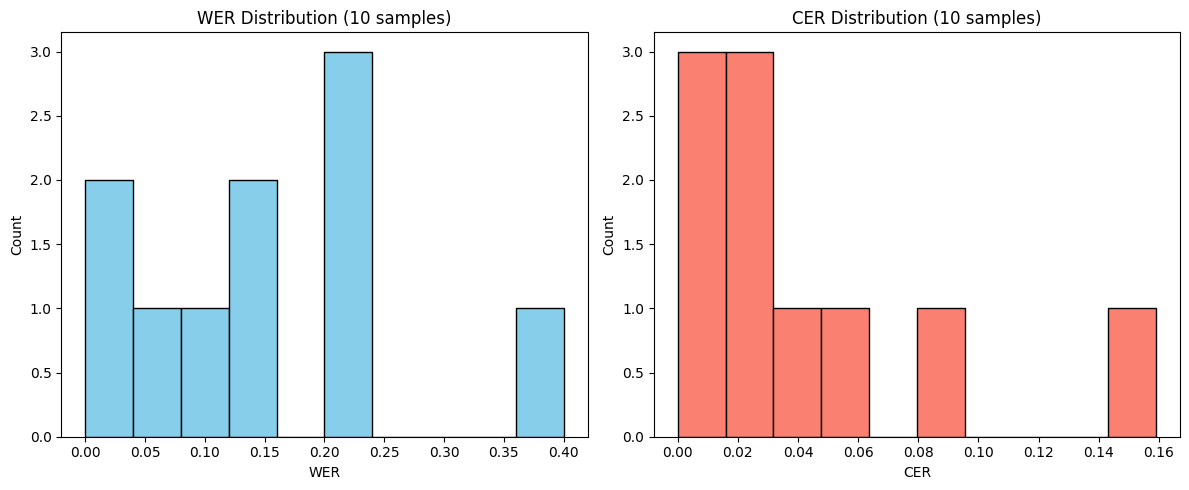

In [24]:
import matplotlib.pyplot as plt
from jiwer import wer, cer

def visualize_error_distribution(df):
    df = df.copy()
    df["wer"] = df.apply(lambda r: wer([r["Actual"]], [r["Predicted"]]), axis=1)
    df["cer"] = df.apply(lambda r: cer([r["Actual"]], [r["Predicted"]]), axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].hist(df["wer"], bins=10, color="skyblue", edgecolor="black")
    axes[0].set_title("WER Distribution (10 samples)")
    axes[0].set_xlabel("WER")
    axes[0].set_ylabel("Count")

    axes[1].hist(df["cer"], bins=10, color="salmon", edgecolor="black")
    axes[1].set_title("CER Distribution (10 samples)")
    axes[1].set_xlabel("CER")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

visualize_error_distribution(results_df)

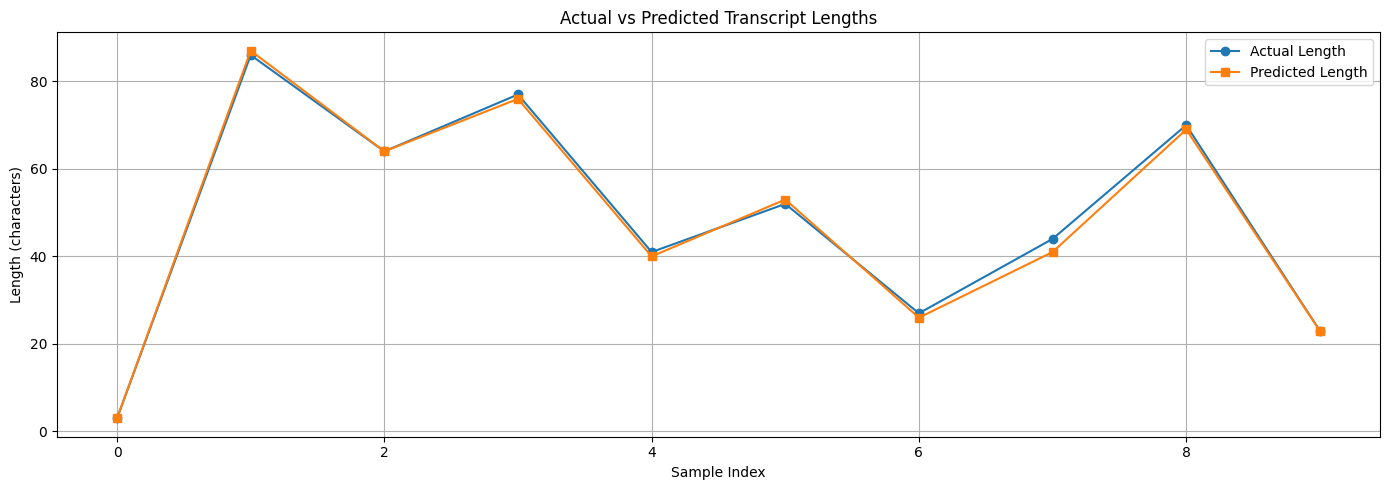

In [25]:
def visualize_length_comparison(df):
    df = df.copy()
    df["actual_len"] = df["Actual"].apply(len)
    df["pred_len"]   = df["Predicted"].apply(len)

    plt.figure(figsize=(14, 5))
    plt.plot(df.index, df["actual_len"], label="Actual Length",    marker="o")
    plt.plot(df.index, df["pred_len"],   label="Predicted Length", marker="s")
    plt.title("Actual vs Predicted Transcript Lengths")
    plt.xlabel("Sample Index")
    plt.ylabel("Length (characters)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

visualize_length_comparison(results_df)

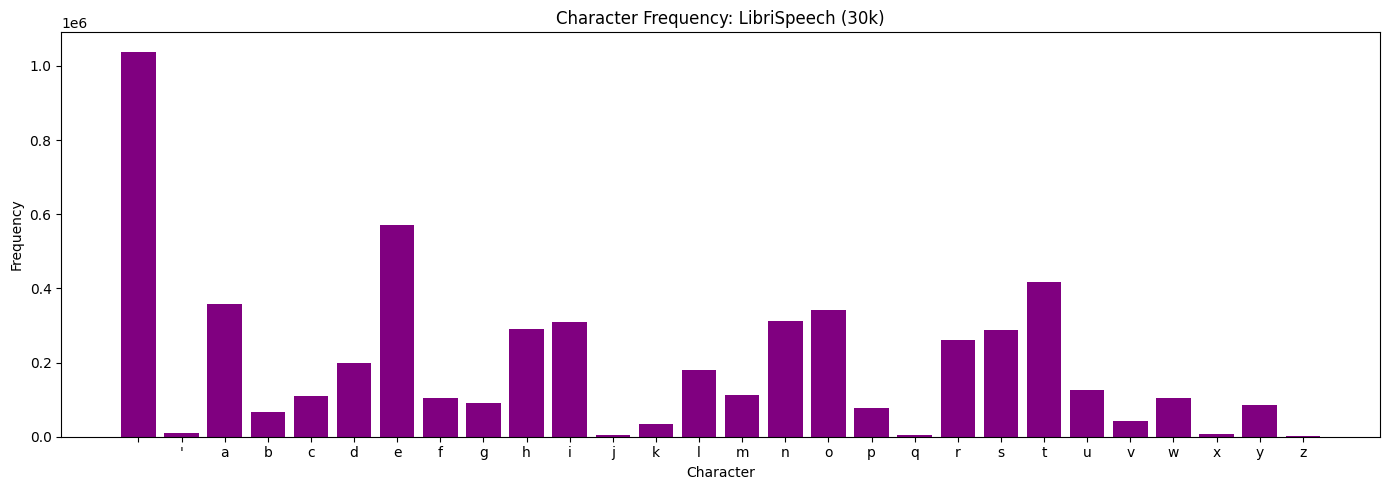

/tmp/ipykernel_258/3301656645.py:14: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


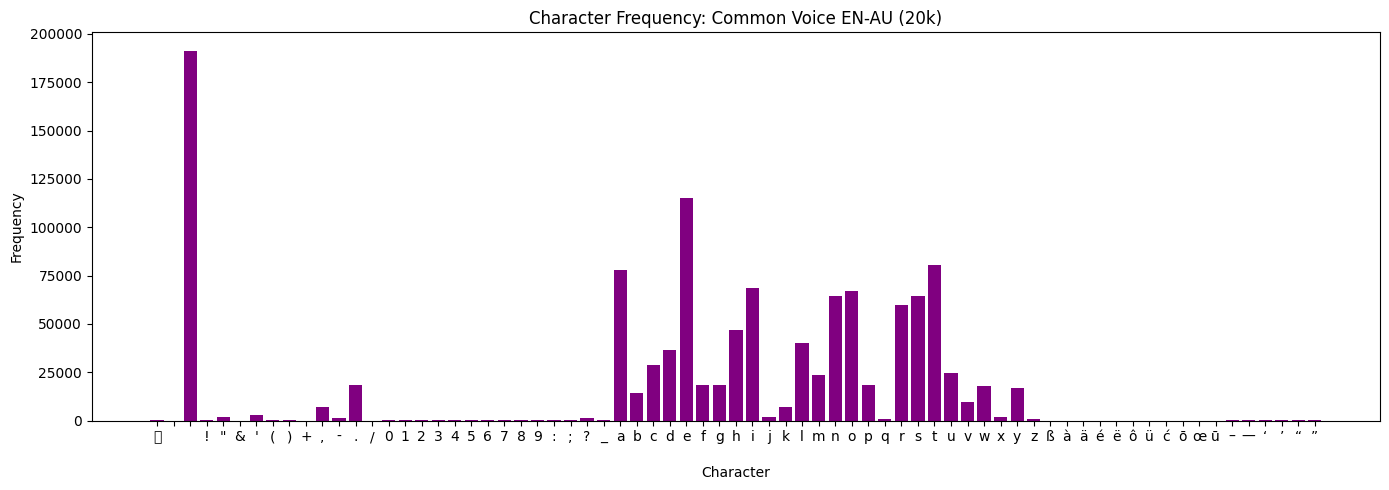

In [26]:
from collections import Counter

def plot_character_distribution(df, title):
    text = " ".join(df["transcript"].str.lower().tolist())
    counter = Counter(text)
    chars = sorted(counter.keys())
    freqs = [counter[c] for c in chars]

    plt.figure(figsize=(14, 5))
    plt.bar(chars, freqs, color="purple")
    plt.title(f"Character Frequency: {title}")
    plt.xlabel("Character")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

plot_character_distribution(df_librispeech, "LibriSpeech (30k)")
plot_character_distribution(cv_df_stage2,  "Common Voice EN-AU (20k)")

In [29]:
!pip install -q ipywidgets

## Interactive Audio Transcription Interface

In [34]:
# Upload an audio file and transcribe it
import ipywidgets as widgets
from IPython.display import display, Audio
import io, torch, torchaudio

uploader = widgets.FileUpload(
    accept='.wav,.flac,.mp3,.ogg,.m4a',
    multiple=False,
    description='Upload Audio',
    layout=widgets.Layout(width='300px')
)

transcribe_btn = widgets.Button(
    description='Transcribe',
    button_style='success',
    layout=widgets.Layout(width='150px')
)

output = widgets.Output()

def on_transcribe(b):
    with output:
        output.clear_output()

        if not uploader.value:
            print("Please upload an audio file first.")
            return

        # handle both old dict format and new tuple format
        raw = uploader.value
        if isinstance(raw, dict):
            # ipywidgets < 8.x
            uploaded_file = list(raw.values())[0]
            audio_bytes   = uploaded_file['content']
            filename      = uploaded_file['metadata']['name']
        else:
            # ipywidgets >= 8.x — value is a tuple of dicts
            uploaded_file = raw[0]
            audio_bytes   = uploaded_file['content']
            filename      = uploaded_file['name']

        print(f"Processing: {filename}")

        # Load audio from bytes
        audio_buffer = io.BytesIO(bytes(audio_bytes))
        speech, sr   = torchaudio.load(audio_buffer)

        print(f"Duration : {speech.shape[-1]/sr:.2f}s  |  Sample rate: {sr} Hz")

        # Resample to 16kHz
        if sr != 16000:
            speech = torchaudio.functional.resample(speech, sr, 16000)
            print(f"Resampled: {sr} Hz → 16000 Hz")

        # Stereo → mono
        if speech.shape[0] > 1:
            speech = speech.mean(dim=0, keepdim=True)
            print("Converted: stereo → mono")

        speech = speech.squeeze().numpy()

        # Truncate if too long
        max_samples = int(15.0 * 16000)
        if len(speech) > max_samples:
            speech = speech[:max_samples]
            print("Truncated: to 15s for memory safety")

        # Run through model
        print("\nRunning inference...")
        inputs         = processor(speech, sampling_rate=16000, return_tensors="pt", padding=True)
        input_values   = inputs.input_values.to(device)
        attention_mask = inputs.attention_mask.to(device)

        model.eval()
        with torch.no_grad():
            logits = model(
                input_values=input_values,
                attention_mask=attention_mask
            ).logits

        pred_ids      = torch.argmax(logits, dim=-1)
        transcription = processor.batch_decode(pred_ids)[0].lower()

        print("\n" + "="*50)
        print("TRANSCRIPTION:")
        print("="*50)
        print(transcription)
        print("="*50)

        # Play back the audio
        display(Audio(speech, rate=16000))

transcribe_btn.on_click(on_transcribe)

display(widgets.VBox([
    widgets.HTML("<h3> Audio Transcription</h3>"),
    widgets.HTML("<p style='color:gray'>Upload a .wav / .flac / .mp3 / .m4a file</p>"),
    uploader,
    transcribe_btn,
    output
]))